<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 5</h1>
    <h2>Teoría de los Circuitos II - R4052</h2>
    <h3>Fabián Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: César Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Consigna

A continuación se muestran 2 circuitos conocidos en un esquema de 3 nodos externos. Tener en cuenta que para el análisis de la red se pueden definir nodos internos.

<img src="./img/consigna_redes.png" width="900" />

**Se pide:**

1. Construir la **Matriz Admitancia Indefinida** para cada caso. En el **BS170** plantear el modelo lineal visto en clase con admitancias y generadores de corriente, que tenga en cuenta: $C_{iss}$, $C_{oss}$, $C_{rss}$ y $g_m$.
2. Para la red T se pide:
   - a) Obtener $\dfrac{V_{23}}{V_{13}}$; $\dfrac{V_{21}}{V_{31}}$ y $\dfrac{V_{12}}{V_{32}}$, explicitando el armado de los cofactores de segundo orden.
   - b) Graficar y observar detenidamente la respuesta de módulo y fase para cada transferencia. Analizar si entre 2 de las transferencias halladas se cumple que son complementarias en módulo: $|T_a + T_b| = 1$.
3. Para el MOS se pide:
   - a) Dada la MAI hallada en 1 obtener los parámetros $Y$ para las configuraciones *source común* y *drain común*.
   - b) Calcular la matriz de parámetros $ABCD$ en configuración source común.


**Propiedades de la MAI:**

- La sumatoria de filas es igual a cero.
- La sumatoria de columnas es igual a cero.
- El determinante de la matriz es igual a cero.
- Todos los cofactores de primer orden son iguales, es decir: $Y_j^i = Y_m^n$

**Bonus**

- 💎 Implementar en Python el armado de la MAI y la obtención de 2a) con los módulos disponibles en pytc2.
- 🥇 Simulación Circuital y medición de los parámetros $Y$ del MOS en configuración drain común. Implementar el modelo SPICE del *BS170*.

***

## Índice

> **Nota:** los hipervínculos funcionan correctamente en JupyterLab y VS Code abiertos localmente. Si el notebook se visualiza desde **GitHub**, los links pueden no redirigir.

1. [Punto 1 — Matriz Admitancia Indefinida (red T y MOS BS170)](#p1)
2. [Punto 2 — Red T: transferencias de tensión y complementariedad](#p2)
3. [Punto 3 — MOS: parámetros Y y ABCD](#p3)

**Bonus:**
- [Bonus 1 — Armado de la MAI y punto 2a en Python con pytc2](#b1)
- [Bonus 2 — Simulación circuital y medición de parámetros Y en drain común](#b2)

---

In [8]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import numpy as np
import sympy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt

try:
    import pytc2
    print('pytc2 cargado desde instalación global')
except ImportError:
    sys.path.insert(0, os.path.abspath('../..'))
    import pytc2
    print('pytc2 cargado desde copia local')

print(f'Versión: {pytc2.__version__}')

from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
from pytc2.general import print_latex, print_subtitle, s, symbfunc2tf
from pytc2.sistemas_lineales import bodePlot

plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 11})

pytc2 cargado desde instalación global
Versión: 0.2.1-local


<a id="p1"></a>

***

## Punto 1 — Matriz Admitancia Indefinida

### Red T (L, L, C)

### Resolución manuscrita

A continuación se incluye el desarrollo manuscrito de la red T y su Matriz Admitancia Indefinida.

<img src="./img/CamScanner%2024-08-2026%2001.10n_1.jpg" width="900" />

### Transcripción

Definiendo las admitancias de los elementos como

$$
Y_L = \frac{1}{sL}, \qquad Y_C = sC,
$$

la Matriz Admitancia Indefinida de la red T, incorporando el nodo interno $4$, es

$$
Y_{\mathrm{ind\_T}} =
\begin{bmatrix}
Y_L & 0 & 0 & -Y_L \\
0 & Y_L & 0 & -Y_L \\
0 & 0 & Y_C & -Y_C \\
-Y_L & -Y_L & -Y_C & 2Y_L + Y_C
\end{bmatrix}.
$$

### MOSFET BS170 — modelo lineal

Modelo de pequeña señal con admitancias $C_{iss}$, $C_{oss}$ y $C_{rss}$, y la fuente de corriente controlada por $g_m V_{gs}$.

### Resolución manuscrita

A continuación se incluye el modelo lineal del BS170, la construcción de su MAI y el comienzo del análisis de sus parámetros.

<img src="./img/CamScanner%2024-08-2026%2001.10n_2.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_3.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_4.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_5.jpg" width="900" />

### Transcripción

Asignando los nodos $1$, $2$ y $3$ a gate, drain y source, respectivamente, la MAI del modelo lineal de alta frecuencia del BS170 resulta

$$
Y_{\mathrm{ind\_MOS}} =
\begin{bmatrix}
 sC_{iss} & -sC_{rss} & -s(C_{iss}-C_{rss}) \\
 g_m-sC_{rss} & sC_{oss} & -g_m-s(C_{oss}-C_{rss}) \\
 -g_m-s(C_{iss}-C_{rss}) & -s(C_{oss}-C_{rss}) & g_m+s(C_{iss}+C_{oss}-2C_{rss})
\end{bmatrix}.
$$

<a id="p2"></a>

***

## Punto 2 — Red T: transferencias de tensión

### 2.a — Cofactores y transferencias $V_{23}/V_{13}$, $V_{21}/V_{31}$, $V_{12}/V_{32}$

### Resolución manuscrita

El desarrollo manuscrito de los cofactores de segundo orden, las transferencias, sus respuestas de módulo y fase, y la comprobación de complementariedad se presenta a continuación.

<img src="./img/CamScanner%2024-08-2026%2001.10n_6.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_7.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_8.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_9.jpg" width="900" />

### Transcripción

Para una transferencia entre un puerto de entrada $i$ y un puerto de salida $o$, ambos referenciados al nodo común $c$, se emplean cofactores de segundo orden:

$$
\frac{V_{oc}}{V_{ic}} =
\frac{\Delta^{i,c}_{o,c}}{\Delta^{i,c}_{i,c}}.
$$

Aplicando este procedimiento a la red T se obtienen, en el dominio de Laplace,

- **Transferencia 1 (pasa-bajos):**

$$
T_1 = \frac{V_{23}}{V_{13}} = \frac{1}{s^2LC+1}.
$$

- **Transferencia 2 (pasa-altos):**

$$
T_2 = \frac{V_{21}}{V_{31}} = \frac{s^2LC}{s^2LC+1}.
$$

- **Transferencia 3 (pasa-altos cruzada):**

$$
T_3 = \frac{V_{12}}{V_{32}} = \frac{s^2LC}{s^2LC+1}.
$$

### 2.b — Respuesta en frecuencia y complementariedad $|T_a + T_b| = 1$

$T_1$ presenta comportamiento pasa-bajos, mientras que $T_2$ y $T_3$ presentan comportamiento pasa-altos. Las tres transferencias tienen la misma frecuencia característica,

$$
\omega_0 = \frac{1}{\sqrt{LC}}.
$$

La complementariedad entre $T_1$ y $T_2$ se verifica algebraicamente como

$$
\left|T_1+T_2\right|
= \left|\frac{1}{s^2LC+1}+\frac{s^2LC}{s^2LC+1}\right|
= \left|\frac{s^2LC+1}{s^2LC+1}\right|
= 1.
$$

Por lo tanto, sus respuestas son complementarias en módulo bajo esta relación.

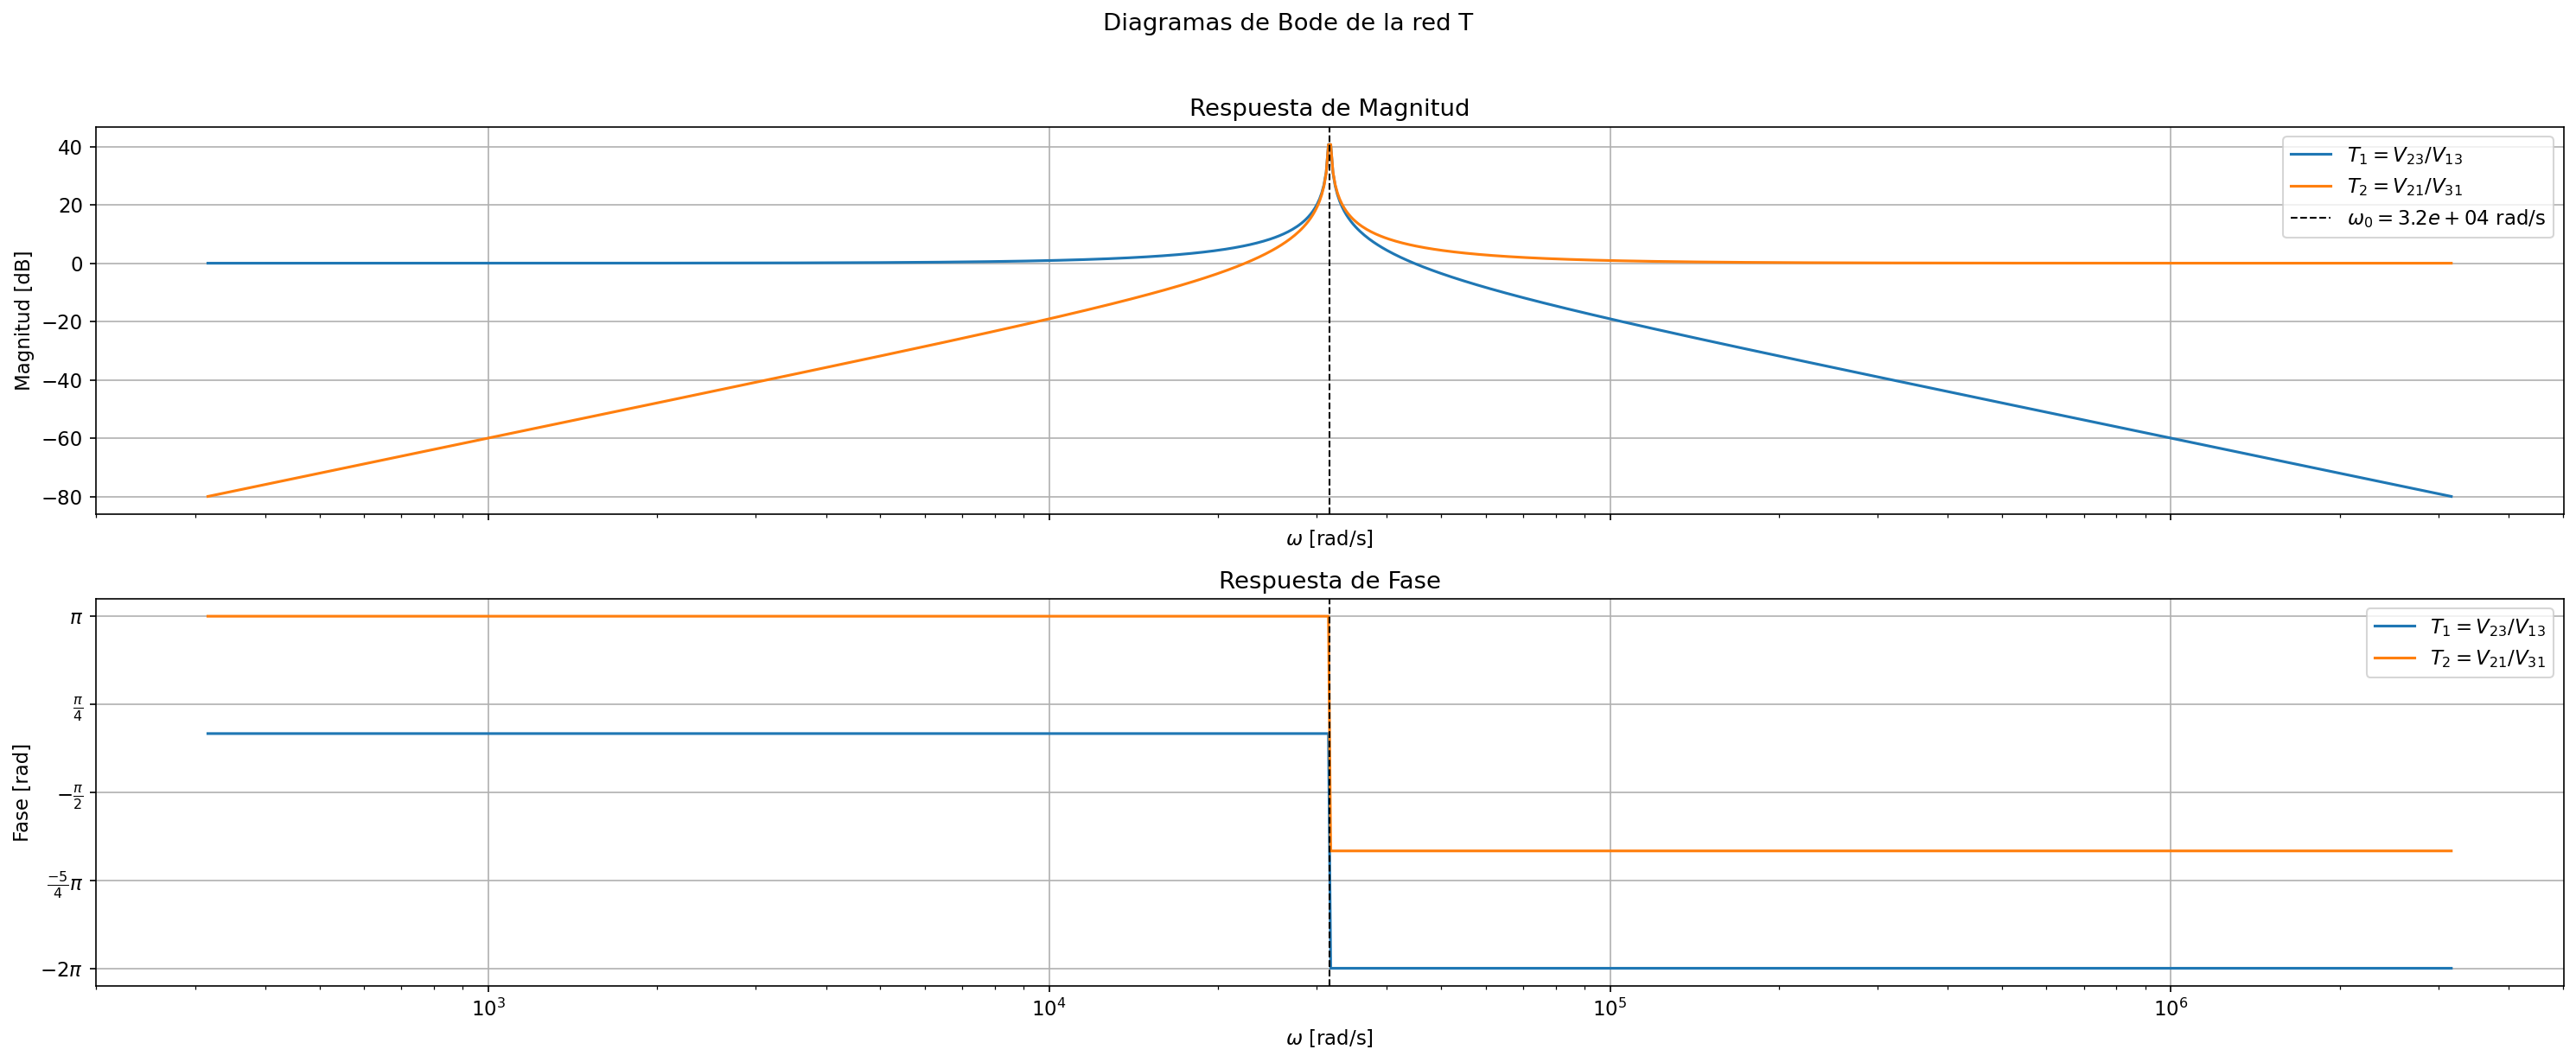

Frecuencia característica: w0 = 3.16e+04 rad/s


In [9]:
# Punto 2 — Diagramas de Bode de T1 y T2

# Valores de referencia para visualizar la respuesta de la red T.
L = 10e-3       # H
C = 100e-9      # F

# Transferencias obtenidas analíticamente en el punto 2.a.
T1 = 1 / (s**2 * L * C + 1)
T2 = s**2 * L * C / (s**2 * L * C + 1)

T1_tf = symbfunc2tf(T1)
T2_tf = symbfunc2tf(T2)

w0 = 1 / np.sqrt(L * C)
# Se evita evaluar exactamente en w0, donde el modelo ideal tiene polos sobre jω.
omega = np.logspace(np.log10(w0) - 2, np.log10(w0) + 2, 1000)

fig_id, axes_hdl = bodePlot(
    T1_tf,
    fig_id='none',
    filter_description=r'$T_1 = V_{23}/V_{13}$',
    worN=omega,
    xaxis='omega',
    unwrap_phase=True,
)

bodePlot(
    T2_tf,
    fig_id=fig_id,
    axes_hdl=axes_hdl,
    filter_description=r'$T_2 = V_{21}/V_{31}$',
    worN=omega,
    xaxis='omega',
    unwrap_phase=True,
)

axes_hdl[0].axvline(w0, color='k', linestyle='--', linewidth=1,
                    label=rf'$\omega_0 = {w0:.2g}\ \mathrm{{rad/s}}$')
axes_hdl[1].axvline(w0, color='k', linestyle='--', linewidth=1)
axes_hdl[0].legend()
axes_hdl[0].set_xlabel(r'$\omega$ [rad/s]')
axes_hdl[1].set_xlabel(r'$\omega$ [rad/s]')
fig = plt.figure(fig_id)
fig.suptitle('Diagramas de Bode de la red T', y=1.02)
fig.tight_layout()
plt.show()

print(f'Frecuencia característica: w0 = {w0:.3g} rad/s')

<a id="p3"></a>

***

## Punto 3 — MOS: parámetros Y y ABCD

### 3.a — Parámetros $Y$ en configuración source común y drain común

### Resolución manuscrita

El desarrollo manuscrito de los parámetros $Y$ para las configuraciones source común y drain común se incluye a continuación.

<img src="./img/CamScanner%2024-08-2026%2001.10n_10.jpg" width="900" />

### Transcripción

Los parámetros $Y$ de cada configuración se obtienen anulando la fila y la columna del nodo conectado a masa en la MAI del modelo del BS170.

Para **source común**, se elimina el nodo $3$:

$$
Y_{\mathrm{SC}} =
\begin{bmatrix}
 sC_{iss} & -sC_{rss} \\
 g_m-sC_{rss} & sC_{oss}
\end{bmatrix}.
$$

Para **drain común**, se elimina el nodo $2$:

$$
Y_{\mathrm{DC}} =
\begin{bmatrix}
 sC_{iss} & -s(C_{iss}-C_{rss}) \\
 -g_m-s(C_{iss}-C_{rss}) & g_m+s(C_{iss}+C_{oss}-2C_{rss})
\end{bmatrix}.
$$

### 3.b — Matriz $ABCD$ en configuración source común

### Resolución manuscrita

El desarrollo de la transformación de parámetros $Y$ a parámetros $ABCD$ se presenta en las siguientes imágenes.

<img src="./img/CamScanner%2024-08-2026%2001.10n_11.jpg" width="900" />

<img src="./img/CamScanner%2024-08-2026%2001.10n_12.jpg" width="900" />

La transformación se realiza mediante

$$
A = \frac{-Y_{22}}{Y_{21}}, \qquad
B = \frac{-1}{Y_{21}}, \qquad
C = \frac{-\Delta_Y}{Y_{21}}, \qquad
D = \frac{-Y_{11}}{Y_{21}},
$$

donde $\Delta_Y = Y_{11}Y_{22}-Y_{12}Y_{21}$. Para la configuración source común se obtiene

$$
\begin{bmatrix}
A & B \\
C & D
\end{bmatrix}
=
\frac{1}{g_m-sC_{rss}}
\begin{bmatrix}
-sC_{oss} & -1 \\
-s^2(C_{iss}C_{oss}-C_{rss}^2)-sg_mC_{rss} & -sC_{iss}
\end{bmatrix}.
$$

<a id="b1"></a>

***

## Bonus 1 — Armado de la MAI y punto 2a en Python (pytc2)

*(Desarrollo pendiente: reproducir con `pytc2` el armado simbólico de la MAI y la obtención de las transferencias del punto 2a.)*

In [10]:
# Bonus 1 — Armado de la MAI y cálculo de transferencias con pytc2

# Admitancias de la red T: nodos externos 1, 2 y 3; nodo interno 4.
L = sp.symbols('L', positive=True, real=True)
C = sp.symbols('C', positive=True, real=True)
YL = 1 / (s * L)
YC = s * C

Ymai_T = sp.Matrix([
    [YL, 0, 0, -YL],
    [0, YL, 0, -YL],
    [0, 0, YC, -YC],
    [-YL, -YL, -YC, 2 * YL + YC],
])

# pytc2 utiliza índices desde cero: nodo 1 -> índice 0, ..., nodo 4 -> índice 3.
T1 = sp.factor(calc_MAI_vtransf_ij_mn(Ymai_T, 1, 2, 0, 2))
T2 = sp.factor(calc_MAI_vtransf_ij_mn(Ymai_T, 1, 0, 2, 0))
T3 = sp.factor(calc_MAI_vtransf_ij_mn(Ymai_T, 0, 1, 2, 1))

print('Matriz Admitancia Indefinida de la red T:')
sp.pprint(Ymai_T)
print('\nTransferencias calculadas mediante cofactores de segundo orden:')
print_latex(r'T_1 = \frac{V_{23}}{V_{13}} = ' + sp.latex(T1))
print_latex(r'T_2 = \frac{V_{21}}{V_{31}} = ' + sp.latex(T2))
print_latex(r'T_3 = \frac{V_{12}}{V_{32}} = ' + sp.latex(T3))

Matriz Admitancia Indefinida de la red T:
⎡ 1                 -1    ⎤
⎢───   0    0       ───   ⎥
⎢L⋅s                L⋅s   ⎥
⎢                         ⎥
⎢      1            -1    ⎥
⎢ 0   ───   0       ───   ⎥
⎢     L⋅s           L⋅s   ⎥
⎢                         ⎥
⎢ 0    0   C⋅s     -C⋅s   ⎥
⎢                         ⎥
⎢-1   -1                2 ⎥
⎢───  ───  -C⋅s  C⋅s + ───⎥
⎣L⋅s  L⋅s              L⋅s⎦

Transferencias calculadas mediante cofactores de segundo orden:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<a id="b2"></a>

***

## Bonus 2 — Simulación circuital y medición de parámetros Y (drain común)

Para verificar experimentalmente los parámetros $Y$ del MOSFET en configuración drain común se utilizó un modelo SPICE del BS170.

### Armado de los circuitos de medición

El transistor se polarizó en continua con

$$
V_{DD}=12\,\mathrm{V},
\qquad
V_{GG}=5\,\mathrm{V},
\qquad
R_s=1\,\mathrm{k}\Omega.
$$

Para extraer experimentalmente los parámetros $Y$ se aplicaron las condiciones de contorno de un cuadripolo mediante dos esquemáticos de prueba sucesivos.

### Medición de $Y_{11}$ e $Y_{21}$

Se conectó un capacitor ideal de valor elevado, $C=10\,\mathrm{F}$, desde el nodo $3$ (source) a masa. De esta manera se genera un cortocircuito de alterna ($V_2=0$) sin modificar el punto de trabajo en continua, mientras se inyecta la señal de excitación en el nodo $2$ (gate).

<img src="./img/bonus2_circuito_medicion_y11_y21.png" width="900" />

Las curvas obtenidas mediante el análisis AC son

<img src="./img/bonus2_resultados_y11_y21.png" width="900" />

Los parámetros medidos en esta configuración se definen como

$$
Y_{11} = \left.\frac{I_1}{V_1}\right|_{V_2=0},
\qquad
Y_{21} = \left.\frac{I_2}{V_1}\right|_{V_2=0}.
$$

### Medición de $Y_{12}$ e $Y_{22}$

Se reubicó el capacitor de cortocircuito hacia el nodo $2$ (gate) y se excitó el nodo $3$ (source) mediante un capacitor de acople, aislando las componentes de corriente continua.

<img src="./img/bonus2_circuito_medicion_y12_y22.png" width="900" />

Las curvas obtenidas mediante el análisis AC son

<img src="./img/bonus2_resultados_y12_y22.png" width="900" />

En esta configuración, los parámetros medidos se definen como

$$
Y_{12} = \left.\frac{I_1}{V_2}\right|_{V_1=0},
\qquad
Y_{22} = \left.\frac{I_2}{V_2}\right|_{V_1=0}.
$$

### Conclusiones de la simulación y medición

- **Implementación de los circuitos de medición:** se configuró el BS170 polarizado en continua y se aplicaron sucesivamente las condiciones de contorno del cuadripolo para medir los cuatro parámetros $Y$.
- **Validación del modelo de pequeña señal:** el barrido en frecuencia, desde $1\,\mathrm{kHz}$ hasta $10\,\mathrm{GHz}$, muestra concordancia teórica con la matriz de parámetros $Y$ deducida analíticamente para la configuración drain común.
- **Admitancia de entrada $Y_{11}$:** presenta un comportamiento estrictamente capacitivo, asociado al término $sC_{iss}$, con una pendiente aproximada de $20\,\mathrm{dB/década}$.
- **Transadmitancia directa $Y_{21}$:** a bajas y medias frecuencias está dominada por el término real de la transconductancia $g_m$, por lo que presenta un comportamiento aproximadamente plano. En frecuencias del orden de los GHz se observa la influencia de las capacidades parásitas.
- **Transadmitancia inversa $Y_{12}$:** presenta un comportamiento capacitivo asociado al término $sC_{rss}$, con una respuesta creciente con la frecuencia.
- **Admitancia de salida $Y_{22}$:** se mantiene aproximadamente constante en gran parte del rango analizado, confirmando el predominio de los términos conductivos del punto de operación. A frecuencias extremas comienzan a observarse los efectos de las capacidades internas.

En conjunto, las mediciones de SPICE validan el modelo lineal de alta frecuencia y permiten comparar experimentalmente los cuatro parámetros con los resultados analíticos del Punto 3.a.